# calcul des bandes s1 utilisée en entrée du modèle à partir des images téléchargées via gee.
On veut deux types d'images : des moyennes mensuelles d'images filtrées avec le filtre de quegan et des moyennes annuelles non moyennées spatialement.  
Via gee, on récupère à la fois une image $\frac{1}{n}\sum_k^n\frac{I_k}{\langle I_k\rangle}$ pour chaque orbite et polarisation et des moyennes mensuelles pour chaque mois, polarisation et orbite.  
On obtient les images mensuelles, filtrées via quegan en moyennant spatialement les moyennes mensuelles et en les multipliant par les moyennes temporelles de ratio.  
On obtient les moyennes annuelles en moyennant les moyennes mensuelles.

In [1]:
import pandas as pd
import geopandas as gpd
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from os.path import join
import shreklib
from concurrent.futures import ProcessPoolExecutor
from rasterio.enums import Resampling
from rasterio.warp import reproject
from affine import Affine
from concurrent.futures import ProcessPoolExecutor
import torch
torch.no_grad()
from torch.nn.functional import avg_pool2d

/usr/local/lib/python3.12/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [ ]:
#chemin du dossier contennant les moyennes mensuelles téléchargées via moyennes_mensuelles.js
means_folder="/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees/input/Sentinel1/Haute_Garonne/gee_S1_intensite/moyennes_mensuelles_gee"

#chemin du dossier contennant les images de moyenne de ratio entre pixel et son voisnnage téléchargées via quegan_terme_temporel.js
ratio_folder="/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees/input/Sentinel1/Haute_Garonne/gee_S1_intensite/temp_ratio"

#chemin vers une image aux crs, dimensions et transformation du projet, pour reprojetter les images à la même grille
ref_grid_img_fps="/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees/input/NISAR/backscatter_stats/ascending_hh.tif"

# reprojection des images dans la grille de référence

In [ ]:
means_fps=glob.glob(join(means_folder, "*.tif"))
ratio_fps=glob.glob(join(ratio_folder, "*.tif"))
with rasterio.open(ref_grid_img_fps, "r") as src:
    ref_transform=src.transform
    ref_height=src.height
    ref_width=src.width
    ref_crs=src.crs

In [ ]:
#fonction de reprojection d'une image spécifiée par son url, à la grille de référence du stage
def reproj_to_ref(in_fp):

    out_folder="/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees/input/Sentinel1/Haute_Garonne/gee_S1_intensite/gee_reprojed"

    out_fp=join(out_folder, os.path.basename(in_fp))

    with rasterio.open(in_fp, "r") as src:
        img=src.read().astype(np.float32) #on charge l'image pour la passer en float 32 dans la reprojection. float64 semble un peu trop.

        profile={
            "crs":ref_crs,
            "transform":ref_transform,
            "width":ref_width,
            "height":ref_height,
            "nodata":np.nan,
            "dtype":"float32", 
            "count": len(img)
            }
        with rasterio.open(out_fp, "w", **profile) as dst:
            reproject(
                source=img, #rasterio.band donne directement les instructions à gdal et ne charge pas tout en mémoire python.
                destination=rasterio.band(dst,list(range(1, len(img)+1))),

                src_transform=src.transform,
                dst_transform=ref_transform,

                src_crs=src.crs,
                dst_crs=ref_crs,

                dst_nodata=np.nan,
                resampling=Resampling.bilinear
            )

In [22]:
with ProcessPoolExecutor(max_workers=32) as executor:
    list(executor.map(reproj_to_ref,ratio_fps+means_fps))
gee_fps=list(map(os.path.basename,glob.glob(join("/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees/input/Sentinel1/Haute_Garonne/gee_S1_intensite/moyennes_mensuelles_gee", "*.tif"))))
reproj_fps=list(map(os.path.basename,glob.glob(join("/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees/input/Sentinel1/Haute_Garonne/gee_S1_intensite/gee_reprojed", "*.tif"))))

manquant=[]
for fp in gee_fps:
    if fp not in reproj_fps:
        manquant.append(fp)

gee_folder="/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees/input/Sentinel1/Haute_Garonne/gee_S1_intensite/moyennes_mensuelles_gee"
with ProcessPoolExecutor(max_workers=32) as executor:
    list(executor.map(reproj_to_ref,[join(gee_folder, filename) for filename in manquant]))

# mosaïques

In [2]:
reprojed=glob.glob(join("/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees/input/Sentinel1/Haute_Garonne/gee_S1_intensite/gee_reprojed", "*.tif"))
reprojed_df=pd.DataFrame({"fp":reprojed, "mosaic_name": [os.path.basename(fp).split("-")[0] for fp in reprojed]})
for id, group in reprojed_df.groupby("mosaic_name"):
    stack=[]
    if id in ['S1_2019_monthly_A_VH', "S1_2019_monthly_A_VV", "S1_2019_monthly_D_VH"]:
        continue
    print(id)
    for i, fp in enumerate(group.fp.tolist()):
        with rasterio.open(fp, "r") as src:
            stack.append(torch.from_numpy(src.read()))

    stack=torch.stack(stack)
    nans=torch.all(torch.isnan(stack), dim=0)
    mosaic=torch.nan_to_num(stack, nan=0).sum(dim=0)
    mosaic=torch.where(nans[None,:,:,:], torch.nan, mosaic).squeeze()

    out_folder="/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees/input/Sentinel1/Haute_Garonne/gee_S1_intensite/moyennes_mensuelles_mosaics"

    shreklib.tif_export(mosaic.numpy(), shreklib.ref_grid["transform"], ref_crs, join(out_folder, id+".tif"), dtype="float32")
with rasterio.open(join(out_folder, "S1_2019_monthly_A_VV.tif"), "r") as src:
    test=src.read(1)

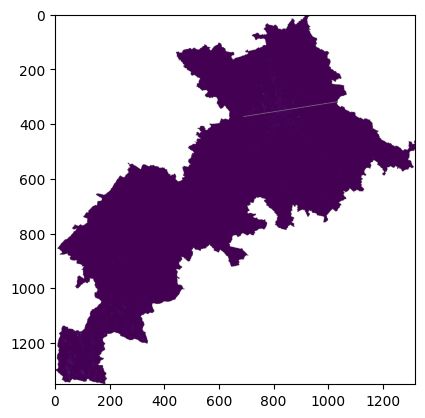

In [10]:
plt.imshow(shreklib.downsample_img(test))

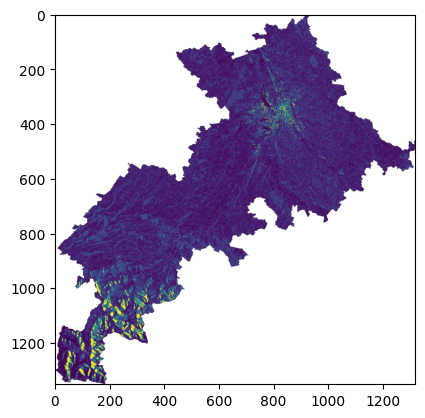

In [56]:
plt.imshow(shreklib.percentile_clip(shreklib.downsample_img(mosaic_nanned[0][11].numpy())))

# on produit les images mensuelles filtrées selon quegan et les moyennes annuelles non filtrées

In [ ]:
out_folder="/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees/input/Sentinel1/Haute_Garonne/gee_S1_intensite/moyennes_mensuelles_mosaics"
gee_mosaics_folder="/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees/input/Sentinel1/Haute_Garonne/gee_S1_intensite/gee_mosaics_to_grid"
ratios_ascending_fps=glob.glob(join(gee_mosaics_folder, "*ratio*ASCENDING*.tif"))[0]
ratio_descending_fps=glob.glob(join(gee_mosaics_folder, "*ratio*DESCENDING*.tif"))[0]

a_vv_fps=glob.glob(join(gee_mosaics_folder, "*_A_*VV*.tif"))[0]
a_vh_fps=glob.glob(join(gee_mosaics_folder, "*_A_*VH*.tif"))[0]
d_vv_fps=glob.glob(join(gee_mosaics_folder, "*_D_*VV*.tif"))[0]
d_vh_fps=glob.glob(join(gee_mosaics_folder, "*_D_*VH*.tif"))[0]
with rasterio.open(ratios_ascending_fps, "r") as src:
    ratio_ascending=torch.from_numpy(src.read())

with rasterio.open(ratio_descending_fps, "r") as src:
    ratio_descending=torch.from_numpy(src.read())
ratios=torch.stack([ratio_ascending, ratio_descending])
del ratio_ascending, ratio_descending
o_map=["A", "D"]
p_map=["VV", "VH"]
fps=[[a_vv_fps, a_vh_fps], [d_vv_fps, d_vh_fps]]
for o in range(2):
    for p in range(2):
        fp=fps[o][p]
        print(fp)
        with rasterio.open(fp, "r") as src:
            mmean=torch.from_numpy(src.read())
        avgpool_mmean=avg_pool2d(mmean,
                kernel_size=5,
                stride=1,
                padding=2)
        queganed=avgpool_mmean*ratios[o, p]

        quegan_folder="/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees/input/Sentinel1/Haute_Garonne/gee_S1_intensite/quegan_mensuel"
        shreklib.tif_export(queganed.numpy(), shreklib.ref_grid["transform"], ref_crs, join(quegan_folder, f"{o_map[o]}_{p_map[p]}_mensuel.tif"), "float32")

        moyenne_annuelle_folder="/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees/input/Sentinel1/Haute_Garonne/gee_S1_intensite/moyennes_annuelles"
        shreklib.tif_export(torch.nanmean(mmean, dim=0).numpy(), shreklib.ref_grid["transform"], ref_crs, join(moyenne_annuelle_folder, f"{o_map[o]}_{p_map[p]}_annuel.tif"), "float32")

# passage en dB, vv/vh et export

In [ ]:
# mensuel
db_folder="/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees/input/Sentinel1/Haute_Garonne/gee_S1_intensite/s1_mensuel_db"
for o in range(2):
    if o==0:
        continue
    ps=[]
    for p in range(2):
        fp=join(quegan_folder, f"{o_map[o]}_{p_map[p]}_mensuel.tif")
        print(fp)
        with rasterio.open(fp, "r") as src:
            ps.append(src.read())
    shreklib.tif_export(10*np.log10(ps[0]), shreklib.ref_grid["transform"], ref_crs, join(db_folder, f"{o_map[o]}_VV_mensuel_db.tif"), dtype="float32")
    shreklib.tif_export(10*np.log10(ps[1]), shreklib.ref_grid["transform"], ref_crs, join(db_folder, f"{o_map[o]}_VH_mensuel_db.tif"), dtype="float32")
    shreklib.tif_export(10*np.log10(ps[0]/ps[1]), shreklib.ref_grid["transform"], ref_crs, join(db_folder, f"{o_map[o]}_VV_VH_mensuel_db.tif"), dtype="float32")
# annuel
db_folder="/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees/input/Sentinel1/Haute_Garonne/gee_S1_intensite/s1_annuel_db"
for o in range(2):
    ps=[]
    for p in range(2):
        fp=join(moyenne_annuelle_folder, f"{o_map[o]}_{p_map[p]}_annuel.tif")
        print(fp)
        with rasterio.open(fp, "r") as src:
            ps.append(src.read())
    shreklib.tif_export(10*np.log10(ps[0]), shreklib.ref_grid["transform"], ref_crs, join(db_folder, f"{o_map[o]}_VV_annuel_db.tif"), dtype="float32")
    shreklib.tif_export(10*np.log10(ps[1]), shreklib.ref_grid["transform"], ref_crs, join(db_folder, f"{o_map[o]}_VH_annuel_db.tif"), dtype="float32")
    shreklib.tif_export(10*np.log10(ps[0]/ps[1]), shreklib.ref_grid["transform"], ref_crs, join(db_folder, f"{o_map[o]}_VV_VH_annuel_db.tif"), dtype="float32")

/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees/input/Sentinel1/Haute_Garonne/gee_S1_intensite/quegan_mensuel/D_VV_mensuel.tif
/mnt/Data/30_Stages_Encours/2026/2026_SHREQ_Niels/02_Donnees/input/Sentinel1/Haute_Garonne/gee_S1_intensite/quegan_mensuel/D_VH_mensuel.tif
